## Theoretical Foundations of Artificial Neural Networks

In the context of machine learning and its applications to quantitative finance, an Artificial Neural Network (ANN) is fundamentally a highly non-linear, parameterized mathematical model designed to map an input space to an output space. By composing multiple linear transformations with non-linear activation functions, NNs serve as universal function approximators capable of learning complex, high-dimensional manifolds from empirical data.

What follows is a formalized theoretical note suitable for an academic repository, detailing the forward propagation, the objective function, and the optimization via backpropagation.

### 1. Network Architecture and Forward Propagation

Consider a strictly feedforward neural network, specifically a Multi-Layer Perceptron (MLP), with $L$ layers. We denote the input layer as layer $0$ and the output layer as layer $L$. The layers $1$ through $L-1$ are termed "hidden layers."

Let $n_l$ represent the number of neurons in layer $l$. The architecture is parameterized by a sequence of weight matrices and bias vectors:
* $W^{(l)} \in \mathbb{R}^{n_l \times n_{l-1}}$ is the weight matrix connecting layer $l-1$ to layer $l$.
* $b^{(l)} \in \mathbb{R}^{n_l}$ is the bias vector for layer $l$.

For a given input vector $x \in \mathbb{R}^{n_0}$, we initialize the network's input state as $a^{(0)} = x$. The forward propagation of information through each subsequent layer $l \in \{1, 2, \dots, L\}$ is defined recursively by two operations:

1.  **Linear Transformation (Pre-activation):**
    $$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}$$
2.  **Non-linear Activation:**
    $$a^{(l)} = \sigma(z^{(l)})$$

Here, $z^{(l)} \in \mathbb{R}^{n_l}$ is the pre-activation vector, $a^{(l)} \in \mathbb{R}^{n_l}$ is the activation vector, and $\sigma(\cdot)$ is a chosen non-linear, element-wise differentiable function (e.g., ReLU, Sigmoid, or $\tanh$). The final output of the network is $\hat{y} = a^{(L)}$.

### 2. Empirical Risk Minimization

The objective of training a neural network is to find the optimal set of parameters $\theta = \{W^{(1)}, b^{(1)}, \dots, W^{(L)}, b^{(L)}\}$ that minimizes a given loss function $\mathcal{L}(\hat{y}, y)$ over a dataset of $N$ observations, $\{(x_i, y_i)\}_{i=1}^N$. 

This framework is known as Empirical Risk Minimization (ERM). The overall cost function $J(\theta)$ is the average loss over the training set:

$$J(\theta) = \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}(f(x_i; \theta), y_i) + \Omega(\theta)$$

Where $f(x_i; \theta) = \hat{y}_i$ is the network's prediction, and $\Omega(\theta)$ represents an optional regularization term (e.g., $L_2$ penalty) to mitigate overfitting, which is a common hazard in financial datasets characterized by low signal-to-noise ratios.

### 3. Optimization and Backpropagation

To minimize $J(\theta)$, we typically employ variants of Gradient Descent. The parameter update rule at iteration $t$, with a learning rate $\eta$, is given by:

$$\theta_{t+1} = \theta_t - \eta \nabla_\theta J(\theta_t)$$

The core challenge lies in computing the gradients of the cost function with respect to the weights and biases of the hidden layers. This is resolved elegantly using the Backpropagation algorithm, which is an application of the multivariable chain rule.

We define an error term $\delta^{(l)}$ for layer $l$, which represents the partial derivative of the cost with respect to the pre-activation $z^{(l)}$:

$$\delta^{(l)} = \frac{\partial \mathcal{L}}{\partial z^{(l)}}$$

The algorithm proceeds in three distinct steps:

**Step 1: Compute Output Layer Error**
For the final layer $L$, the error term depends directly on the chosen loss function:
$$\delta^{(L)} = \nabla_{a^{(L)}} \mathcal{L} \odot \sigma'(z^{(L)})$$
*(Note: $\odot$ denotes the Hadamard, or element-wise, product, and $\sigma'$ is the derivative of the activation function).*

**Step 2: Backpropagate the Error**
For each hidden layer $l = L-1, L-2, \dots, 1$, the error is propagated backward:
$$\delta^{(l)} = \left( (W^{(l+1)})^T \delta^{(l+1)} \right) \odot \sigma'(z^{(l)})$$

**Step 3: Compute the Gradients**
Once the error terms are evaluated for all layers, the gradients with respect to the parameters are computed as:
$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \delta^{(l)} (a^{(l-1)})^T$$
$$\frac{\partial \mathcal{L}}{\partial b^{(l)}} = \delta^{(l)}$$

These individual gradients are then averaged over the mini-batch (or the entire dataset) to perform the update step $\nabla_\theta J(\theta_t)$.

### 4. The Universal Approximation Theorem

From a theoretical standpoint, the utilization of MLPs is justified by the Universal Approximation Theorem. Informally, it states that a feedforward network with a linear output layer and at least one hidden layer containing a finite number of neurons (equipped with a non-constant, bounded, and monotonically-increasing continuous activation function) can approximate any continuous function on a compact subset of $\mathbb{R}^n$ to arbitrary precision, provided the hidden layer is sufficiently wide. While theoretically profound, in practice, deep architectures (larger $L$) are generally preferred over infinitely wide ones due to their enhanced representational efficiency and superior feature hierarchy extraction.

Train accuracy: 0.9833333333333333
Test accuracy: 0.9666666666666667


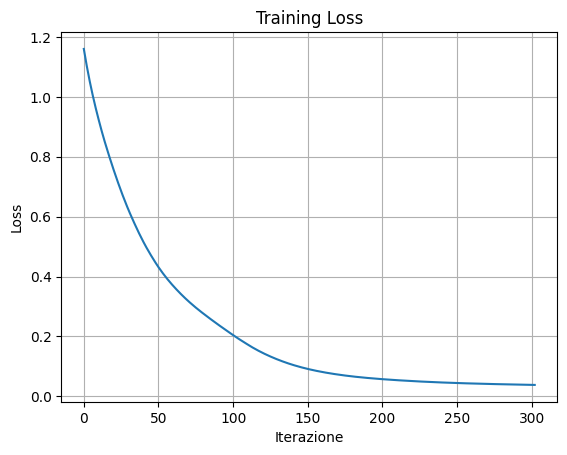

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

data = load_iris()
X = data.data
y = data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

plt.plot(model.loss_curve_)
plt.title("Training Loss")
plt.xlabel("Iterazione")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

NN train accuracy: 0.983
NN test accuracy:  0.967
NN generalization gap: 0.017

Linear model train accuracy: 0.958
Linear model test accuracy:  0.933
Linear model generalization gap: 0.025


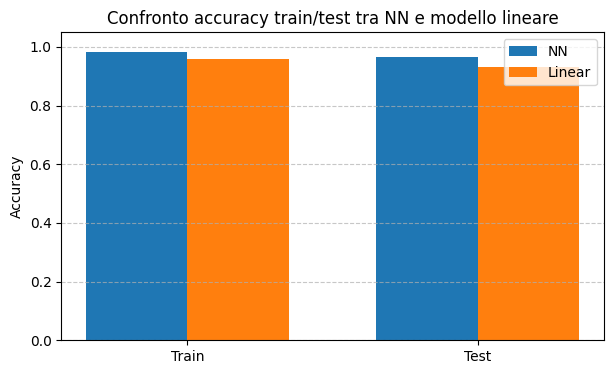

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_train_pred_nn = model.predict(X_train)
y_test_pred_nn = model.predict(X_test)
y_train_pred_lr = logreg.predict(X_train)
y_test_pred_lr = logreg.predict(X_test)

acc_train_nn = accuracy_score(y_train, y_train_pred_nn)
acc_test_nn = accuracy_score(y_test, y_test_pred_nn)
gap_nn = acc_train_nn - acc_test_nn

acc_train_lr = accuracy_score(y_train, y_train_pred_lr)
acc_test_lr = accuracy_score(y_test, y_test_pred_lr)
gap_lr = acc_train_lr - acc_test_lr

print(f"NN train accuracy: {acc_train_nn:.3f}")
print(f"NN test accuracy:  {acc_test_nn:.3f}")
print(f"NN generalization gap: {gap_nn:.3f}\n")

print(f"Linear model train accuracy: {acc_train_lr:.3f}")
print(f"Linear model test accuracy:  {acc_test_lr:.3f}")
print(f"Linear model generalization gap: {gap_lr:.3f}")

labels = ['Train', 'Test']
nn_scores = [acc_train_nn, acc_test_nn]
lr_scores = [acc_train_lr, acc_test_lr]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, nn_scores, width, label='NN')
plt.bar(x + width/2, lr_scores, width, label='Linear')
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.title('Confronto accuracy train/test tra NN e modello lineare')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()